# 19 · Model solution: pension fund portfolio

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lukasquaderer-lgtm/Linear-regression/blob/master/notebooks/solutions/19_project_pension_portfolio_solution.ipynb)

One reasonable solution. The main design choice: expected returns are too noisy to optimise on (notebook 17, Section 4),
so this solution uses **only the covariance matrix** (Ledoit–Wolf, 2-year window) and compares three rule-compliant
constructions: minimum variance, risk parity and maximum diversification, each capped at the current allocation's risk.

In [1]:
# Setup: run this cell first (Shift + Enter). Works in Jupyter, VS Code and Google Colab.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   # hide library deprecation notices

# Use the local data folder if it exists, otherwise read the CSVs straight from GitHub (e.g. in Colab)
DATA = next((p for p in ["../data/", "../../data/"] if Path(p).exists()), "https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/data/")
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (8, 4)

# Answer checker: after an exercise, check("01.1") tells you whether your answer is right
import sys
if Path("../checks.py").exists():
    sys.path.insert(0, "..")  # solution notebooks live one folder down
try:
    from checks import check, check_all
except ImportError:  # in Colab: fetch the checker from GitHub
    import urllib.request
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/notebooks/checks.py", "checks.py")
    from checks import check, check_all
print("Ready. Data folder:", DATA)

Ready. Data folder: ../../data/


In [2]:
rets = pd.read_csv(DATA + "asset_returns_daily.csv", index_col=0, parse_dates=True)
assets = list(rets.columns)
BENCH = pd.Series({"CH_EQUITY": 0.20, "WORLD_EQUITY": 0.15, "EM_EQUITY": 0.05, "CHF_BONDS": 0.30,
                   "GLOBAL_BONDS": 0.10, "GOLD": 0.05, "SWISS_REAL_ESTATE": 0.15, "COMMODITIES": 0.00})[assets]
GROUPS = {"equities": ["CH_EQUITY", "WORLD_EQUITY", "EM_EQUITY"], "real estate": ["SWISS_REAL_ESTATE"],
          "alternatives": ["GOLD", "COMMODITIES"]}
LIMITS = {"equities": 0.50, "real estate": 0.30, "alternatives": 0.15}   # inspired by Swiss pension rules (BVV 2)
MAX_SINGLE = 0.35
print(rets.shape, "| current strategic allocation:"); print(BENCH)

(3912, 8) | current strategic allocation:
CH_EQUITY            0.20
WORLD_EQUITY         0.15
EM_EQUITY            0.05
CHF_BONDS            0.30
GLOBAL_BONDS         0.10
GOLD                 0.05
SWISS_REAL_ESTATE    0.15
COMMODITIES          0.00
dtype: float64


In [3]:
from scipy.optimize import minimize
from scipy import stats
from sklearn.covariance import LedoitWolf
ANN, RF, COST = 252, 0.005, 0.001
idx = {g: [assets.index(a) for a in m] for g, m in GROUPS.items()}

def rule_constraints(vol_cap=None, S=None):
    cons = [{"type": "eq", "fun": lambda w: w.sum() - 1}]
    for g, lim in LIMITS.items():
        cons.append({"type": "ineq", "fun": lambda w, ix=idx[g], lim=lim: lim - w[ix].sum()})
    if vol_cap is not None:
        cons.append({"type": "ineq", "fun": lambda w: vol_cap ** 2 - w @ S @ w})
    return cons

def solve(obj, S, vol_cap=None, x0=None):
    x0 = BENCH.to_numpy() if x0 is None else x0
    res = minimize(obj, x0, method="SLSQP", bounds=[(0, MAX_SINGLE)] * len(assets),
                   constraints=rule_constraints(vol_cap, S), options={"maxiter": 1000, "ftol": 1e-12})
    return np.clip(res.x, 0, None) / np.clip(res.x, 0, None).sum()

def min_var(S, cap):  return solve(lambda w: w @ S @ w, S, cap)
def max_div(S, cap):
    sd = np.sqrt(np.diag(S)); return solve(lambda w: -(w @ sd) / np.sqrt(w @ S @ w), S, cap)
def risk_par(S, cap):
    def obj(w):
        rc = w * (S @ w) / np.sqrt(w @ S @ w); return ((rc - rc.mean()) ** 2).sum() * 1e4
    return solve(obj, S, cap, x0=np.full(len(assets), 1 / len(assets)))

def check_rules(w):
    w = pd.Series(w, index=assets)
    ok = abs(w.sum() - 1) < 1e-6 and (w >= -1e-9).all() and (w <= MAX_SINGLE + 1e-6).all()
    ok &= all(w[m].sum() <= LIMITS[g] + 1e-6 for g, m in GROUPS.items())
    return bool(ok)
print("current allocation respects the rules:", check_rules(BENCH))

current allocation respects the rules: True


In [4]:
def risk_report(r, w=None, S=None):
    g = (1 + r).cumprod(); q = np.quantile(r, 0.01)
    rep = {"ann. return": r.mean() * ANN, "ann. vol": r.std() * np.sqrt(ANN), "Sharpe": (r.mean() * ANN - RF) / (r.std() * np.sqrt(ANN)),
           "max drawdown": (g / g.cummax() - 1).min(), "VaR 99% 1-day": -q, "ES 99% 1-day": -r[r <= q].mean(),
           "VaR 99% 1-month (√21)": -q * np.sqrt(21), "Feb–Mar 2020 loss": (1 + r.loc["2020-02-20":"2020-03-16"]).prod() - 1}
    return pd.Series(rep)

S_full = rets.cov().to_numpy() * ANN
b = BENCH.to_numpy()
r_bench_static = rets @ BENCH
rc = b * (S_full @ b) / np.sqrt(b @ S_full @ b)
print("1) Current allocation:"); print(risk_report(r_bench_static).round(4))
print("\nRisk contributions (share of volatility):"); print(pd.Series(rc / rc.sum(), index=assets).round(3))

1) Current allocation:
ann. return              0.0497
ann. vol                 0.0792
Sharpe                   0.5647
max drawdown            -0.2739
VaR 99% 1-day            0.0130
ES 99% 1-day             0.0168
VaR 99% 1-month (√21)    0.0594
Feb–Mar 2020 loss       -0.0876
dtype: float64

Risk contributions (share of volatility):
CH_EQUITY            0.362
WORLD_EQUITY         0.277
EM_EQUITY            0.105
CHF_BONDS            0.050
GLOBAL_BONDS         0.023
GOLD                 0.022
SWISS_REAL_ESTATE    0.161
COMMODITIES          0.000
dtype: float64


**Task 1 finding:** the three equity sleeves are 40% of the money but around three quarters of the risk; bonds are 40%
of the money and contribute almost nothing. The real question for the committee is therefore how much equity risk to
run, not how to fine-tune the bond split.

**Task 2 choices:** covariance from Ledoit–Wolf on the last 2 years (recent enough to track changing volatility, long
enough to be stable, shrinkage to tame noise). No expected-return estimates: their standard errors (about 4% a year for
equities, notebook 17) are as large as the premiums themselves. Instead, each construction is capped at the current
allocation's volatility so the committee compares like with like.

4) Walk-forward 2012-2024, all rules enforced at every rebalancing:
                     ann. return  ann. vol  Sharpe  max drawdown  \
Current allocation        0.0564    0.0796  0.6456       -0.2739   
1/N within rules          0.0627    0.0933  0.6189       -0.3073   
Min variance              0.0159    0.0468  0.2321       -0.2358   
Risk parity               0.0279    0.0563  0.4065       -0.2569   
Max diversification       0.0210    0.0499  0.3199       -0.2441   

                     VaR 99% 1-day  ES 99% 1-day  VaR 99% 1-month (√21)  \
Current allocation          0.0130        0.0172                 0.0596   
1/N within rules            0.0157        0.0199                 0.0718   
Min variance                0.0075        0.0090                 0.0343   
Risk parity                 0.0089        0.0112                 0.0408   
Max diversification         0.0081        0.0096                 0.0370   

                     Feb–Mar 2020 loss  avg monthly turnover  
Current a

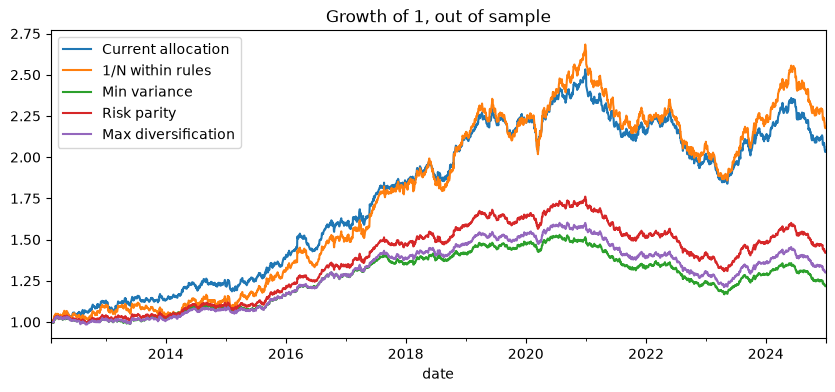

In [5]:
# 3) + 4) walk-forward: monthly, 2-year Ledoit-Wolf window, rules enforced at every date
try:
    month_ends = rets.resample("ME").last().index
except ValueError:
    month_ends = rets.resample("M").last().index
LOOK = 504
builders = {"Current allocation": lambda S, cap: b,
            "1/N within rules": lambda S, cap: solve(lambda w: ((w - 1 / len(assets)) ** 2).sum(), S),
            "Min variance": min_var, "Risk parity": risk_par, "Max diversification": max_div}
paths = {k: [] for k in builders}; weights = {k: [] for k in builders}; turnover = {k: [] for k in builders}; prev = {k: np.zeros(len(assets)) for k in builders}
for i, me in enumerate(month_ends[:-1]):
    hist = rets.loc[:me].iloc[-LOOK:]
    if len(hist) < LOOK or me < pd.Timestamp("2012-01-01"):
        continue
    S = LedoitWolf().fit(hist.to_numpy()).covariance_ * ANN
    cap = np.sqrt(b @ S @ b)                                    # never riskier than the current allocation (ex ante)
    nxt = rets.loc[(rets.index > me) & (rets.index <= month_ends[i + 1])]
    for k, f in builders.items():
        w = f(S, cap); assert check_rules(w), (k, me)
        r = nxt.to_numpy() @ w; t = np.abs(w - prev[k]).sum(); r[0] -= COST * t
        paths[k].append(pd.Series(r, index=nxt.index)); weights[k].append(pd.Series(w, index=assets, name=me)); turnover[k].append(t); prev[k] = w
R = pd.DataFrame({k: pd.concat(v) for k, v in paths.items()})
table = R.apply(risk_report).T; table["avg monthly turnover"] = {k: np.mean(v[1:]) for k, v in turnover.items()}
print("4) Walk-forward 2012-2024, all rules enforced at every rebalancing:"); print(table.round(4))
(1 + R).cumprod().plot(figsize=(10, 4), title="Growth of 1, out of sample"); plt.show()

**Choosing:** write the decision rule down *before* looking at the results, and include the current allocation as a
candidate. Here the rule is: recommend a change only if a new construction beats the current allocation's Sharpe ratio
without a deeper maximum drawdown. Otherwise the honest recommendation is to keep the current allocation, possibly
with a smaller, well-understood tilt. Simplification to note in the memo: returns assume the target weights are held
daily, and costs are charged only at the monthly rebalancing.

Best new construction: Risk parity | beats current allocation on the rule: False
5) Proposal: Risk parity. Latest weights (rules OK: True):
CH_EQUITY            0.064
WORLD_EQUITY         0.060
EM_EQUITY            0.050
CHF_BONDS            0.336
GLOBAL_BONDS         0.247
GOLD                 0.088
SWISS_REAL_ESTATE    0.093
COMMODITIES          0.062
Name: 2024-11-30 00:00:00, dtype: float64
                                                    Current allocation  \
ann. return                                                     0.0564   
ann. vol                                                        0.0796   
Sharpe                                                          0.6456   
max drawdown                                                   -0.2739   
VaR 99% 1-day                                                   0.0130   
ES 99% 1-day                                                    0.0172   
VaR 99% 1-month (√21)                                           0.0596   
Feb–Mar 20

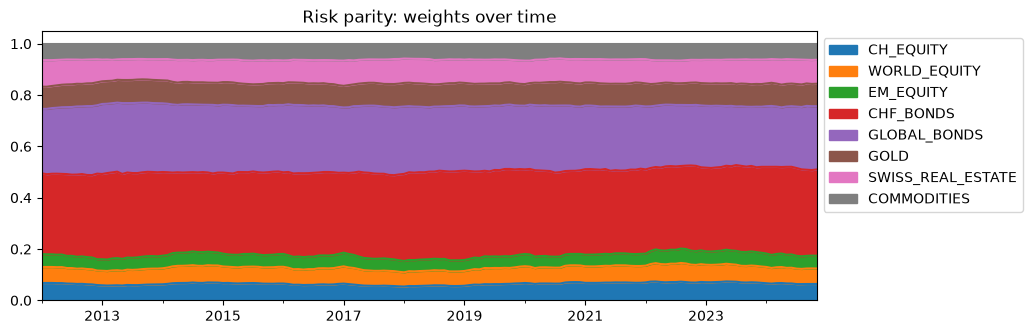

In [6]:
# 5) apply the decision rule stated above
cands = ["Min variance", "Risk parity", "Max diversification"]
best = table.loc[cands, "Sharpe"].idxmax()
cur = table.loc["Current allocation"]
switch = table.loc[best, "Sharpe"] > cur["Sharpe"] and table.loc[best, "max drawdown"] >= cur["max drawdown"]
pick = best        # analysed below either way, so the committee sees the trade-off
print(f"Best new construction: {best} | beats current allocation on the rule: {switch}")
W_hist = pd.DataFrame(weights[pick]); w_now = W_hist.iloc[-1]
print(f"5) Proposal: {pick}. Latest weights (rules OK: {check_rules(w_now)}):"); print(w_now.round(3))
side = pd.DataFrame({"Current allocation": table.loc["Current allocation"], pick: table.loc[pick]})
custom = {"CHF +15% shock (foreign assets −15%, CHF assets −2%)": pd.Series({a: (-0.02 if a in ["CH_EQUITY", "CHF_BONDS", "SWISS_REAL_ESTATE"] else -0.15) for a in assets})}
for name, s in custom.items():
    side.loc[name] = [s @ BENCH, s @ w_now]
print(side.round(4))
W_hist.plot.area(figsize=(10, 3.5), title=f"{pick}: weights over time"); plt.legend(bbox_to_anchor=(1, 1)); plt.show()

In [7]:
# 6) attribution versus the current allocation
active = R[pick] - R["Current allocation"]
te = active.std() * np.sqrt(ANN); ir = active.mean() * ANN / te
print(f"6) active return {active.mean() * ANN:.2%} a year | tracking error {te:.2%} | information ratio {ir:.2f}")
avg_w = W_hist.mean()
period = R.index
asset_ret = (1 + rets.loc[period]).prod() ** (ANN / len(period)) - 1           # annualised asset returns over the test period
Rb = BENCH @ asset_ret
alloc = (avg_w - BENCH) * (asset_ret - Rb)
print("Allocation effect by asset (average active weight × (asset return − benchmark return)):"); print(alloc.round(4))
print(f"sum of allocation effects ≈ {alloc.sum():.2%} a year (selection is zero: both portfolios hold the same asset-class indices)")

6) active return -2.85% a year | tracking error 3.66% | information ratio -0.78
Allocation effect by asset (average active weight × (asset return − benchmark return)):
CH_EQUITY           -0.0065
WORLD_EQUITY        -0.0064
EM_EQUITY           -0.0000
CHF_BONDS           -0.0017
GLOBAL_BONDS        -0.0075
GOLD                -0.0030
SWISS_REAL_ESTATE   -0.0022
COMMODITIES         -0.0005
dtype: float64
sum of allocation effects ≈ -2.77% a year (selection is zero: both portfolios hold the same asset-class indices)


### 7) Investment committee memo
Generated from the results above, so it stays honest if you change the data or the settings.

In [8]:
c, p_ = table.loc["Current allocation"], table.loc[pick]
eq_risk = (rc / rc.sum())[[assets.index(a) for a in GROUPS["equities"]]].sum()
if switch:
    rec = (f"Replace the current allocation with a rule-based {pick} portfolio, rebalanced monthly from a two-year risk "
           f"estimate. Out of sample (2012-2024) it improved the Sharpe ratio from {c['Sharpe']:.2f} to {p_['Sharpe']:.2f} "
           f"without a deeper drawdown.")
else:
    rec = (f"Keep the current strategic allocation. The best risk-based alternative ({pick}) cut volatility from "
           f"{c['ann. vol']:.1%} to {p_['ann. vol']:.1%} and the Feb-Mar 2020 loss from {c['Feb–Mar 2020 loss']:.1%} to "
           f"{p_['Feb–Mar 2020 loss']:.1%}, but annual return fell from {c['ann. return']:.1%} to {p_['ann. return']:.1%} "
           f"and the Sharpe ratio from {c['Sharpe']:.2f} to {p_['Sharpe']:.2f}. Lower risk was paid for with too much return, "
           f"because the extra bonds earned almost nothing.")
memo = f"""INVESTMENT COMMITTEE MEMO - Strategic allocation review

Recommendation: {rec}

Today's risk: equities are 40% of assets but {eq_risk:.0%} of portfolio volatility. 1-day 99% VaR is {c['VaR 99% 1-day']:.2%}
(about CHF {c['VaR 99% 1-day'] * 2e9 / 1e6:.0f} million on CHF 2 billion); the worst drawdown since 2012 was {c['max drawdown']:.1%}.

Options if the board wants less risk: a partial move toward {pick} (for example halfway) lowers volatility and stress
losses at a known cost in expected return; the table above quantifies both ends.

Main risks of the analysis: one 13-year sample, simulated data, returns that assume daily rebalancing. Before any change,
re-test with 1- and 3-year estimation windows and with real index data."""
print(memo)

INVESTMENT COMMITTEE MEMO - Strategic allocation review

Recommendation: Keep the current strategic allocation. The best risk-based alternative (Risk parity) cut volatility from 8.0% to 5.6% and the Feb-Mar 2020 loss from -8.8% to -4.7%, but annual return fell from 5.6% to 2.8% and the Sharpe ratio from 0.65 to 0.41. Lower risk was paid for with too much return, because the extra bonds earned almost nothing.

Today's risk: equities are 40% of assets but 74% of portfolio volatility. 1-day 99% VaR is 1.30%
(about CHF 26 million on CHF 2 billion); the worst drawdown since 2012 was -27.4%.

Options if the board wants less risk: a partial move toward Risk parity (for example halfway) lowers volatility and stress
losses at a known cost in expected return; the table above quantifies both ends.

Main risks of the analysis: one 13-year sample, simulated data, returns that assume daily rebalancing. Before any change,
re-test with 1- and 3-year estimation windows and with real index data.
